In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch.nn as nn
from torch.nn import functional as F

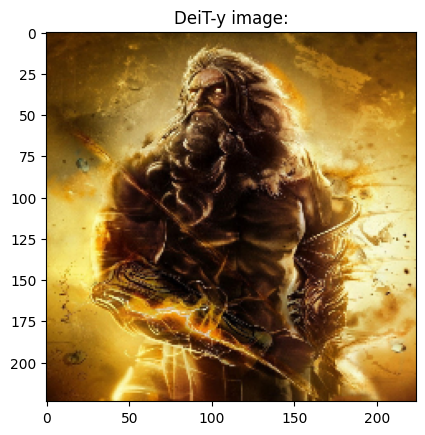

To check img_torch: torch.Size([1, 3, 224, 224])
To check patches shape: torch.Size([1, 16, 14, 14])


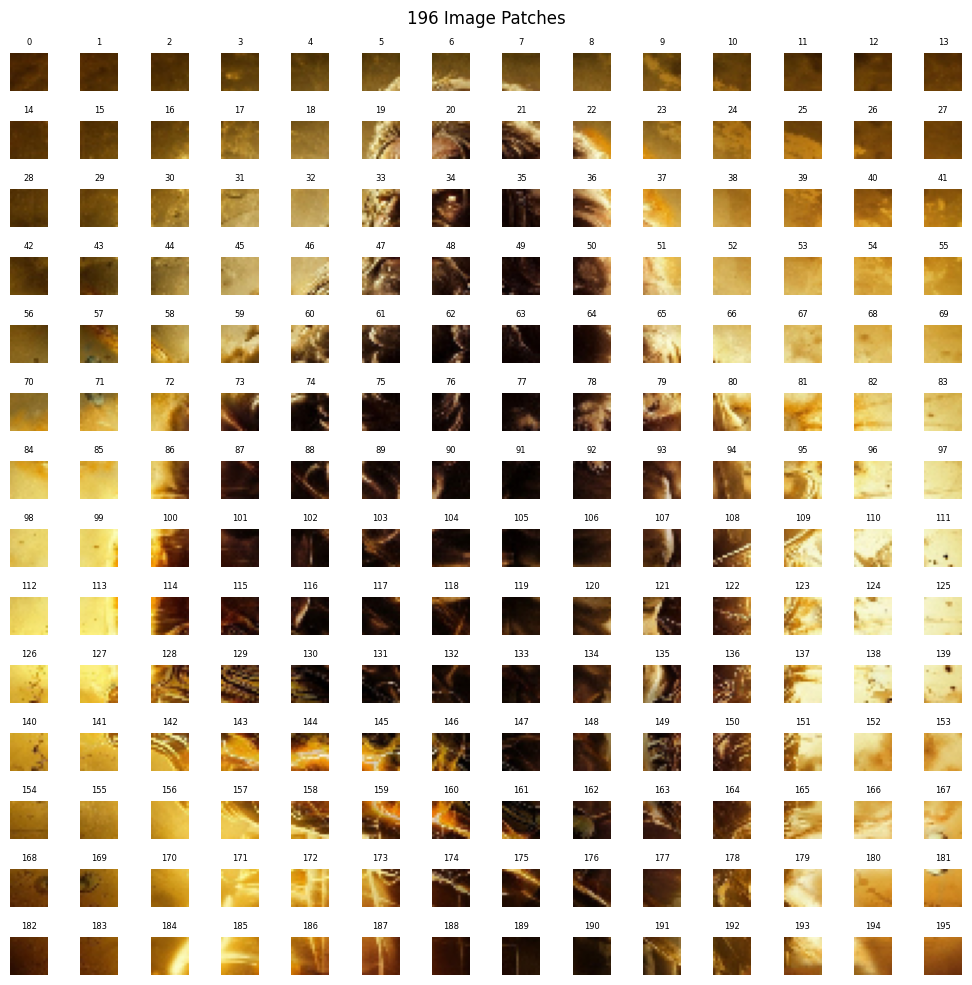

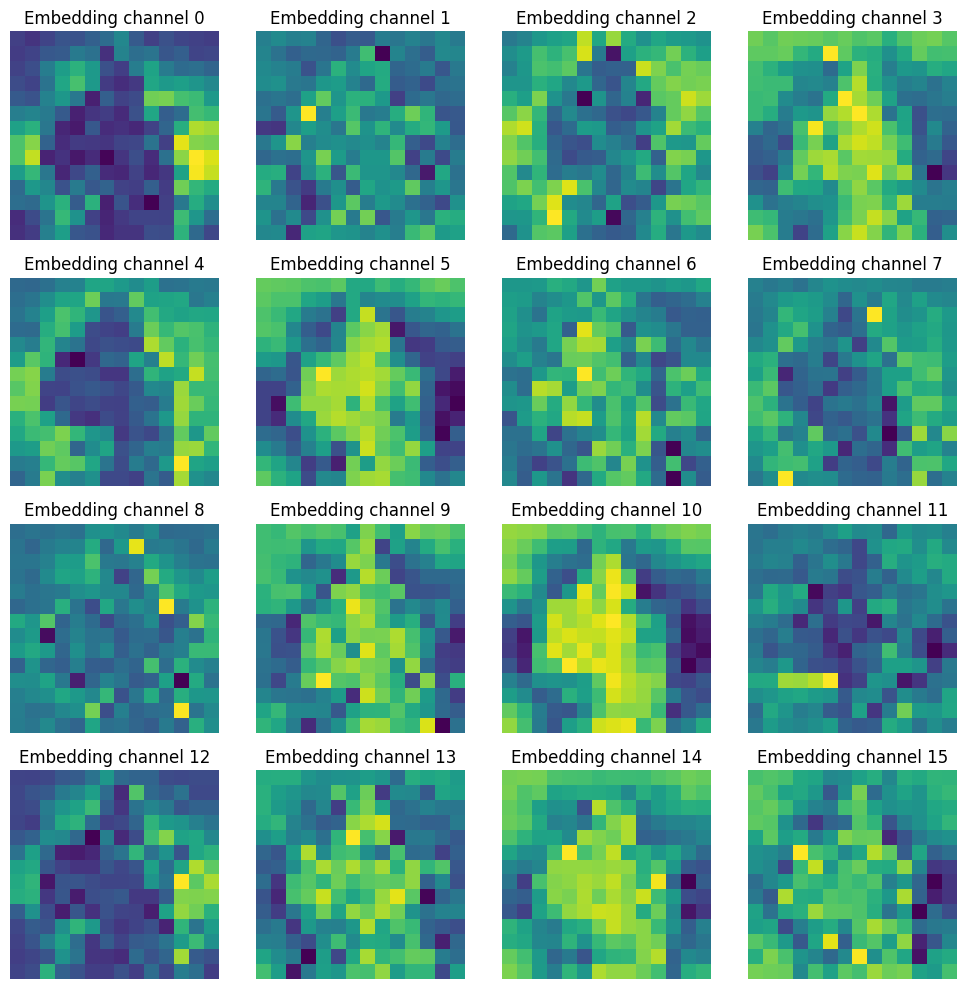

To check: torch.Size([1, 196, 16])
To check dist patch: torch.Size([1, 198, 16])


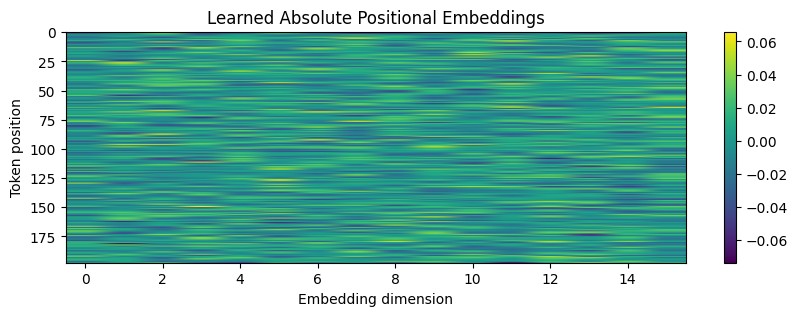

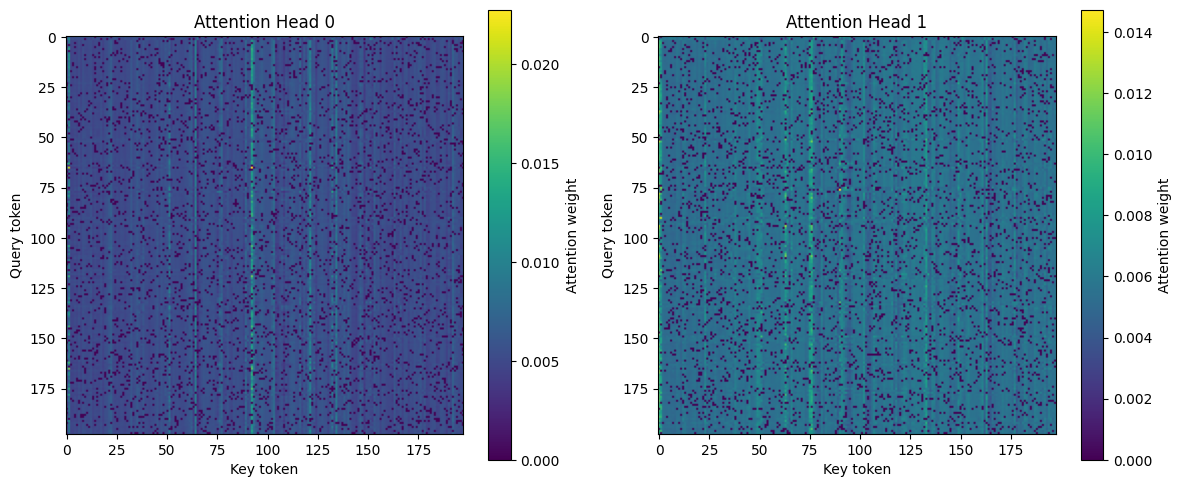

Cls Attention shape would be: torch.Size([196]) which is 14 X 14.


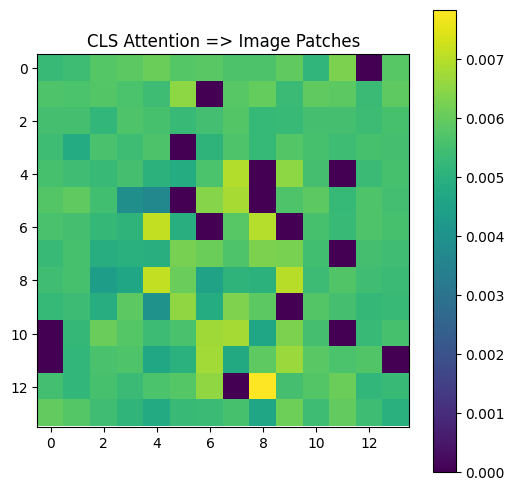

To check result_normed: torch.Size([1, 198, 16])
To check cls, dist: torch.Size([1, 16]), torch.Size([1, 16])
To understand cls_logits, dist_logits: torch.Size([1, 32]), torch.Size([1, 32])


In [12]:
img = cv2.imread("zeus.jpg")
img = cv2.resize(img, (224, 224))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.title("DeiT-y image:")
plt.imshow(img)
plt.show()

# img_import
img_np = np.array(img)
img_torch = torch.from_numpy(img_np)
img_torch = (img_torch/255.0).permute(2, 0, 1).unsqueeze(0)
print(f"To check img_torch: {img_torch.shape}")

#patch_embed
embed_dim = 16
patch_size = 16
patch_embed = nn.Conv2d(in_channels = 3, out_channels = embed_dim, kernel_size = patch_size, stride = patch_size, padding = 'valid')

patches = patch_embed(img_torch)
print(f"To check patches shape: {patches.shape}")

# To see beautiful visualization of the patches
fig, axes = plt.subplots(14, 14, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    row = i // 14
    col = i % 14

    patch = img[
        row * patch_size:(row + 1) * patch_size,
        col * patch_size:(col + 1) * patch_size
    ]

    ax.imshow(patch)
    ax.set_title(str(i), fontsize=6)
    ax.axis("off")

plt.suptitle("196 Image Patches")
plt.tight_layout()
plt.show()

# patch_embed features visualization

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(patches[0, i].detach().numpy())
    ax.set_title(f"Embedding channel {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()


patches = patches.flatten(2).permute(0, 2, 1)
print(f"To check: {patches.shape}")

# addition of cls + dist_token
dist_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
nn.init.trunc_normal_(cls_token, std = 0.02)
nn.init.trunc_normal_(dist_token, std = 0.02)

B = patches.shape[0]
dist_patch = torch.cat((cls_token.expand(B, -1, -1), dist_token.expand(B, -1, -1), patches), dim = 1)
print(f"To check dist patch: {dist_patch.shape}")

# add positional embeddings

# DeiT uses learned absolute positional embeddings
pos_embed = nn.Parameter(torch.zeros(1, dist_patch.shape[1], embed_dim))
nn.init.trunc_normal_(pos_embed, std = 0.02)
emb_rep = dist_patch + pos_embed

#pos embed visualization
plt.figure(figsize=(10, 3))

plt.imshow(
    pos_embed[0].detach().numpy(),
    aspect="auto"
)

plt.xlabel("Embedding dimension")
plt.ylabel("Token position")
plt.title("Learned Absolute Positional Embeddings")
plt.colorbar()
plt.show()

# let us create a DeiT encoder block
X = emb_rep
n_heads = 2
# why do we even need nn.Sequential
ln1 = nn.LayerNorm(embed_dim, eps = 1e-6)
w_q, w_k, w_v, w_o = nn.Linear(embed_dim, embed_dim), nn.Linear(embed_dim, embed_dim), nn.Linear(embed_dim, embed_dim), nn.Linear(embed_dim, embed_dim)

B, G, _ = X.shape
normed = ln1(X)
Q = w_q(normed)
K = w_k(normed)
V = w_v(normed)

d_head = embed_dim // n_heads
Q = Q.reshape(B, G, n_heads, d_head).transpose(1, 2)
K = K.reshape(B, G, n_heads, d_head).transpose(1, 2)
V = V.reshape(B, G, n_heads, d_head).transpose(1, 2)

attn_wts = F.softmax(torch.matmul(Q, K.transpose(-2, -1))/torch.sqrt(torch.tensor(d_head)), dim = -1)
# dropout [PUSHKAL]
attn_wts = F.dropout(attn_wts, 0.1, training=True)

#attn_wts visualization
fig, axes = plt.subplots(1, n_heads, figsize=(12, 5))

for h in range(n_heads):

    im = axes[h].imshow(
        attn_wts[0, h].detach().numpy()
    )

    axes[h].set_title(f"Attention Head {h}")
    axes[h].set_xlabel("Key token")
    axes[h].set_ylabel("Query token")

    # Add color scale
    fig.colorbar(im, ax=axes[h], label="Attention weight")

plt.tight_layout()
plt.show()

#cls attention visualization
cls_attention = attn_wts[0, 0, 0, 2:]
print(f"Cls Attention shape would be: {cls_attention.shape} which is 14 X 14.")

cls_attention = cls_attention.reshape(14, 14)

plt.figure(figsize=(6, 6))
plt.imshow(cls_attention.detach().numpy())
plt.title("CLS Attention => Image Patches")
plt.colorbar()
plt.show()

context = attn_wts @ V
context = context.transpose(1, 2).contiguous().reshape(B, G, embed_dim)
attn_out = F.dropout(w_o(context), 0.1, training = True)

keep = 1 - 0.1
mask = torch.empty(B, 1, 1).bernoulli_(keep) # why bernoulli??
X = X + attn_out*mask/keep

ln_pre_mlp = nn.LayerNorm(embed_dim, eps = 1e-6)
normed_mlp = ln_pre_mlp(X)

mlp = nn.Sequential(
    nn.Linear(embed_dim, embed_dim*4),
    nn.GELU(),
    nn.Linear(embed_dim*4, embed_dim)
)


mask = torch.empty(B, 1, 1).bernoulli_(keep)
X = X + mlp(normed_mlp)*mask/keep

final_ln = nn.LayerNorm(embed_dim)
result_normed = final_ln(X)
print(f"To check result_normed: {result_normed.shape}")

# getting the cls token and thve DIST token

cls_token, dist_token = result_normed[:, 0], result_normed[:, 1]
print(f"To check cls, dist: {cls_token.shape}, {dist_token.shape}")

num_classes = 32
dist_head = nn.Linear(embed_dim, num_classes)

dist_logits = dist_head(dist_token)

cls_head = nn.Linear(embed_dim, num_classes)
cls_logits = cls_head(cls_token)

print(f"To understand cls_logits, dist_logits: {cls_logits.shape}, {dist_logits.shape}")

In [ ]:
# lets get the teacher CNN
# we will not be training a CNN from scratch although we will implement one for the sake of it
from torchvision.models import resnet50, ResNet50_Weights

teacher = nn.Sequential(
    nn.Conv2d(3, 64, 3, stride = 2, padding = 1),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 128, 3, stride = 2, padding = 1),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 128, 3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 256, 3, stride=2, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, 3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 512, 3, stride=2, padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(512, num_classes),

)
# just to make one

teacher = resnet50(weights = ResNet50_Weights.IMAGENET1K_V2)
print("Seeing the imported pretrained model:")
print(teacher)


teacher.fc = nn.Linear(teacher.fc.in_features, num_classes)

for p in teacher.parameters():
  p.requires_grad = False
teacher.eval()
# why are we freezing the teacher

with torch.no_grad():
  teacher_logits = teacher(img_torch)

  print(f"Let us see the teacher logits: {teacher_logits.shape, teacher_logits[0][0]}")
  teacher_labels = teacher_logits.argmax(dim = -1)
  print(f"Let us view teacher_labels: {teacher_labels}")


  y_true = torch.tensor([7])

  loss_cls = F.cross_entropy(cls_logits, y_true)
  loss_dist = F.cross_entropy(dist_logits, teacher_labels)

  loss = 0.5*loss_cls + 0.5*loss_dist
  print(f"To check loss: {loss}")
  # loss.backward()




Seeing the imported pretrained model:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64